In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def humedad_rango(
    year_start = 2018,
    year_end = 2019,
    sep=",",
):
    col_lugar="palua"
    csv_path="../../data/raw/factores influyentes/Humedad especifica - Hoja 1.csv"
    col_fecha="fecha"
    formato_fecha="%Y-%m-%d"

    df = pd.read_csv(csv_path, sep=sep)
    df.columns = df.columns.str.strip()

    meses = list(range(1, 13))
    nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]


    # Convertir fecha y ordenar
    df[col_fecha] = pd.to_datetime(df[col_fecha], format=formato_fecha, errors="coerce")
    df = df.dropna(subset=[col_fecha]).sort_values(col_fecha)

    if df.empty:
        raise ValueError("No hay datos para el rango de años seleccionado.")

    plt.figure(figsize=(13, 5))

    for year in range(year_start,year_end + 1):
        s = (
            df[df["fecha"].dt.year == year]
            .groupby(df["fecha"].dt.month)[col_lugar]
            .mean()
            .reindex(meses)
        )
        plt.plot(meses, s, marker="o", label=str(year), linestyle="-")

    plt.xticks(meses, nombres_meses)
    plt.xlabel("Mes")
    plt.ylabel("Humedad del especifica (%)")
    plt.title(f'Humedad del especifica en {col_lugar} ({year_start} - {year_end})')
    plt.grid(True, alpha=0.3)

    plt.legend(title="Años")
    plt.tight_layout()
    plt.show()

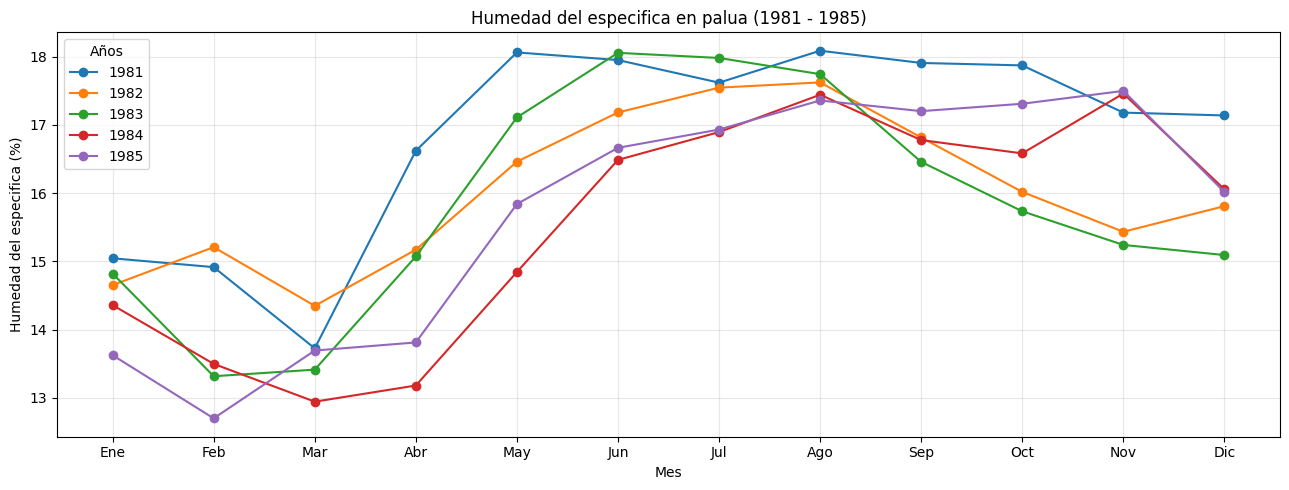

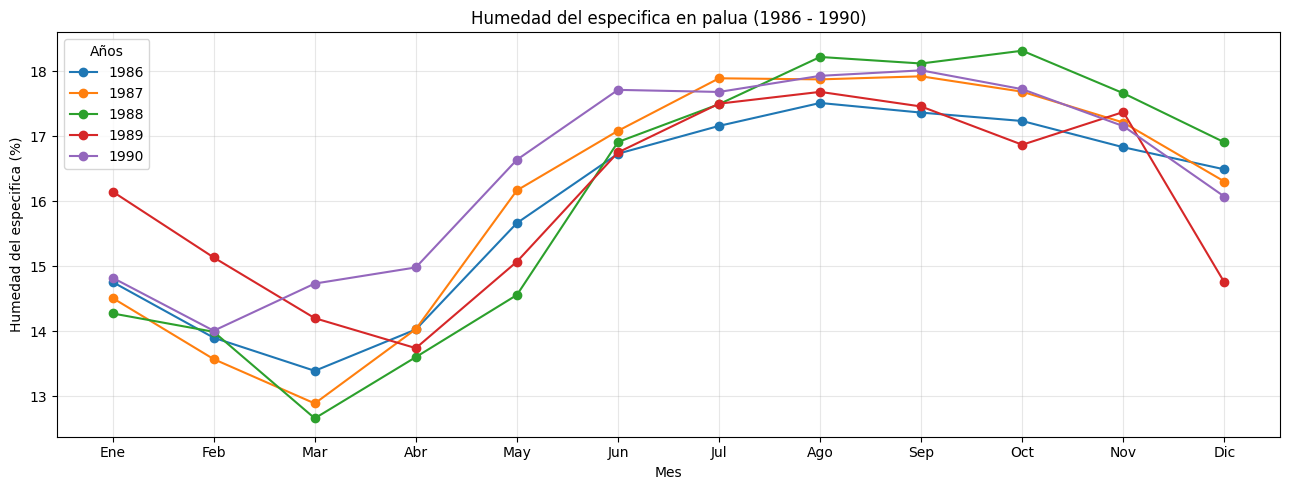

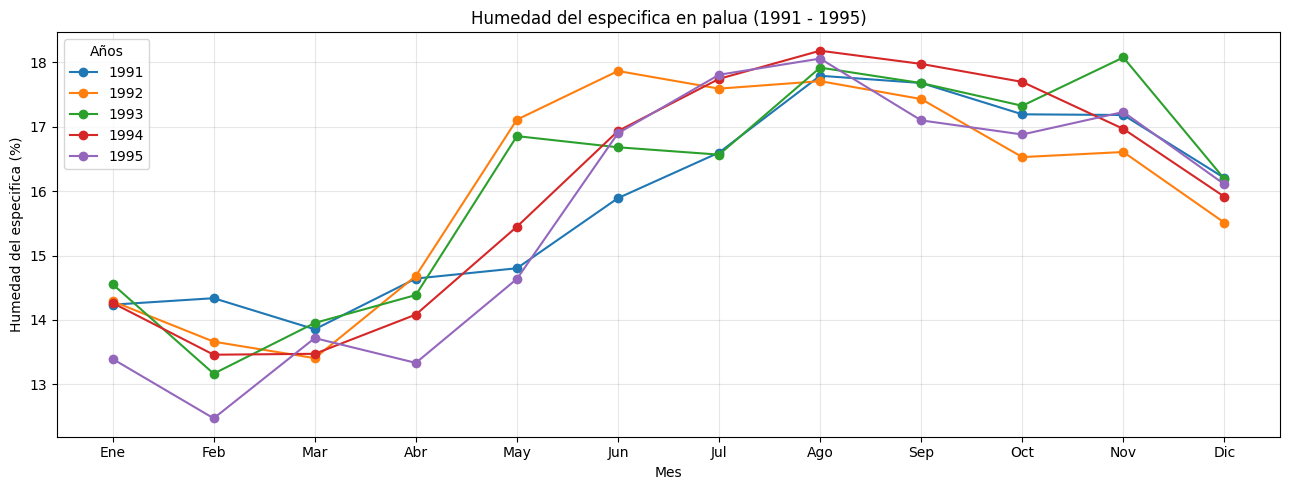

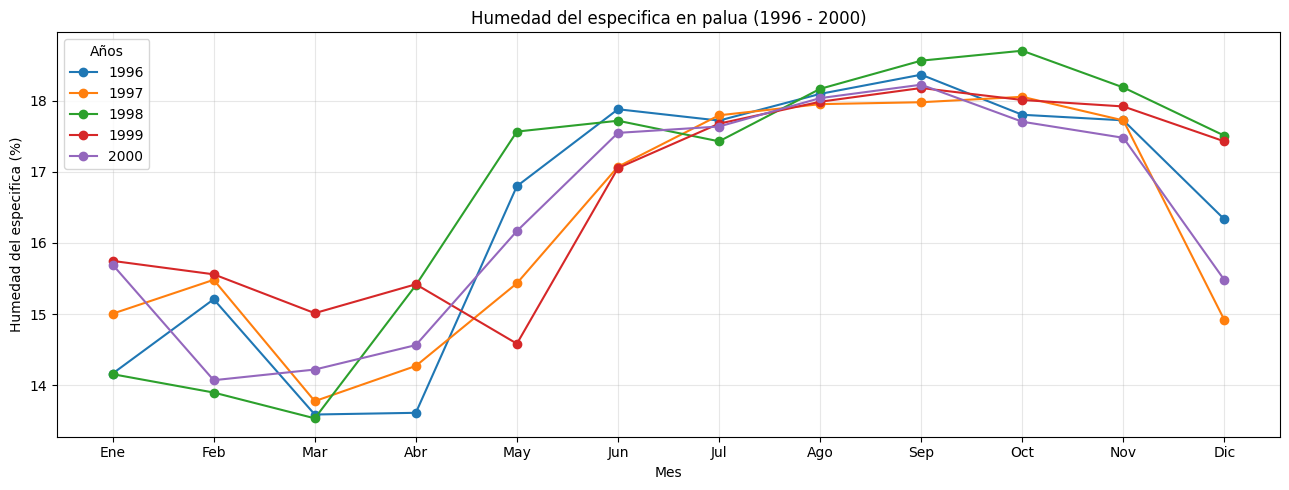

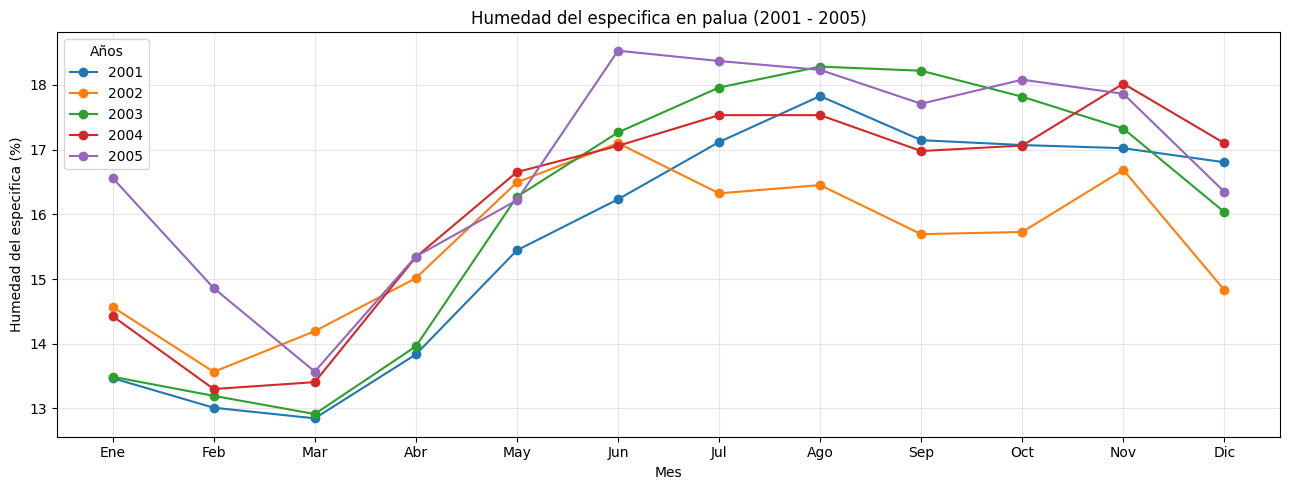

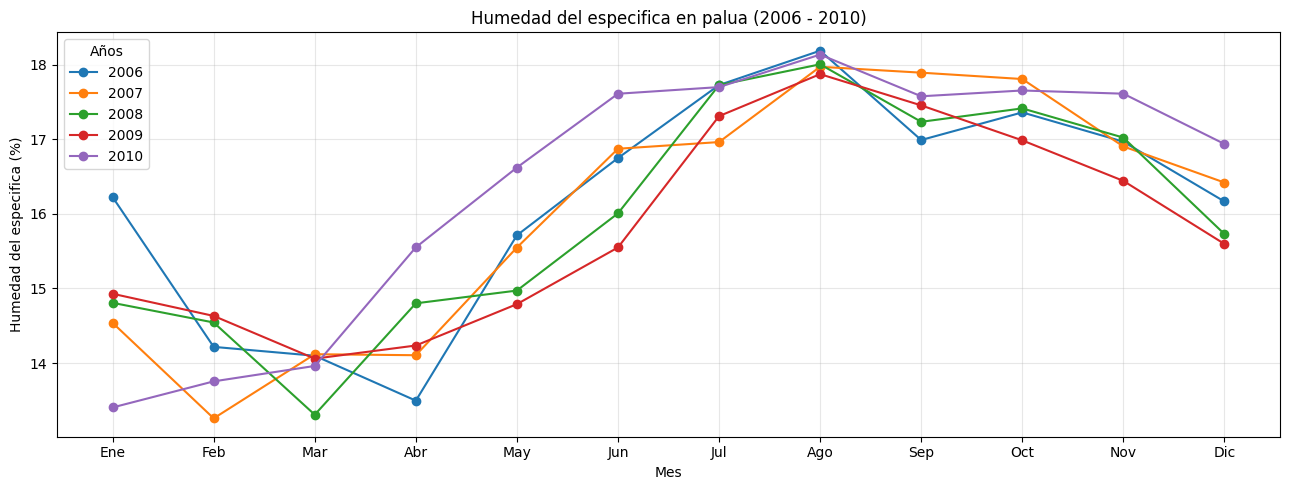

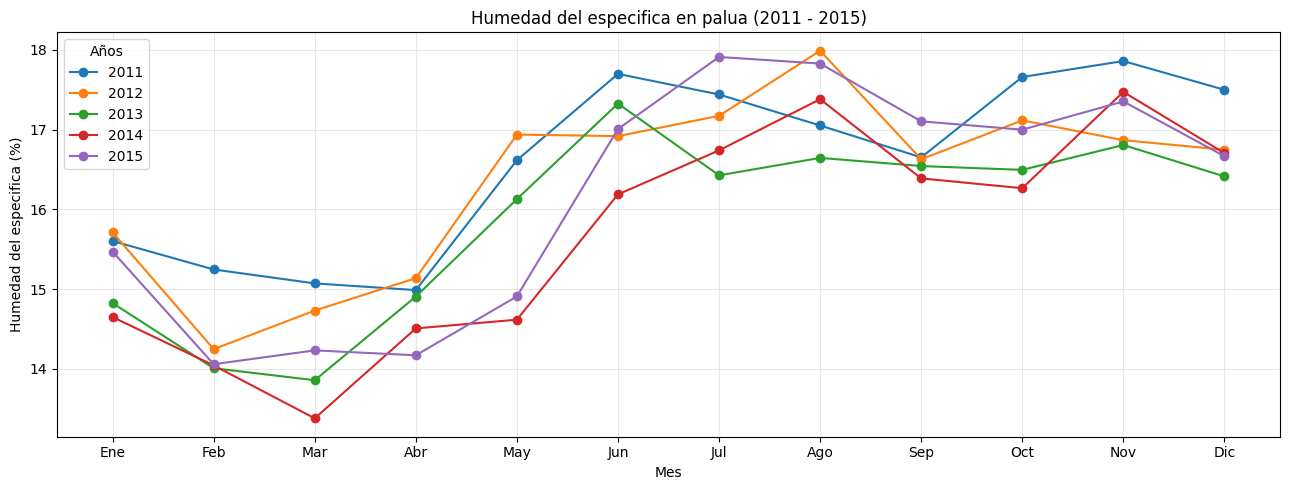

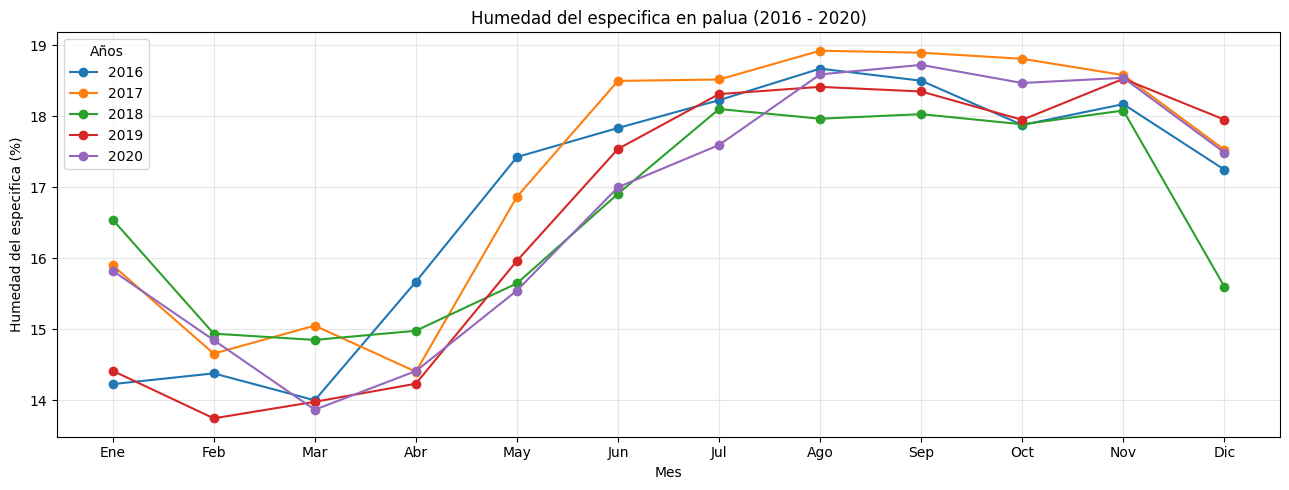

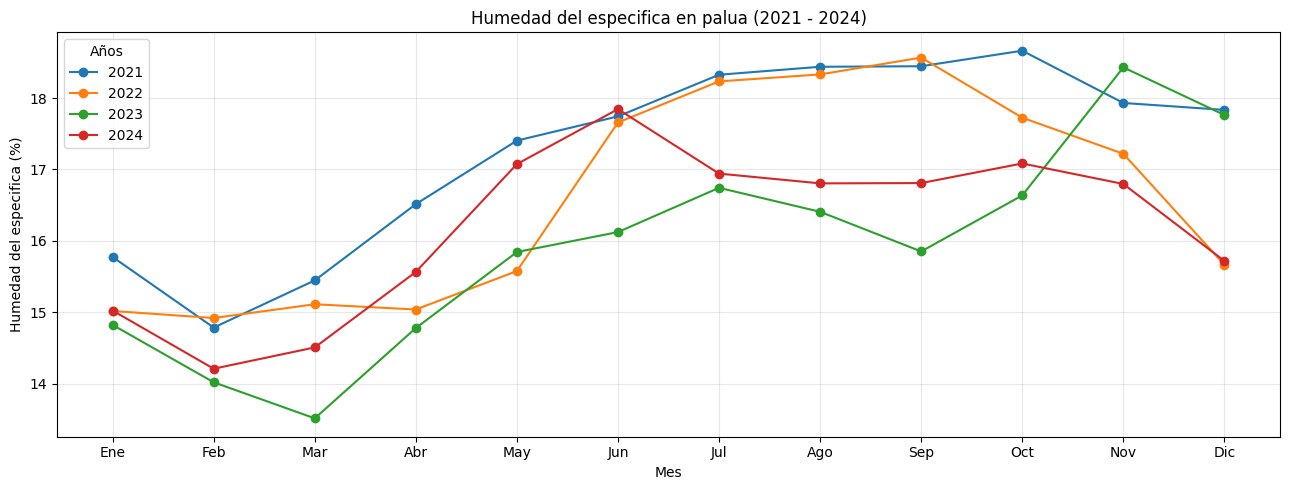

In [2]:
humedad_rango(
    year_start=1981,
    year_end=1985
)
humedad_rango(
    year_start=1986,
    year_end=1990
)
humedad_rango(
    year_start=1991,
    year_end=1995
)
humedad_rango(
    year_start=1996,
    year_end=2000
)
humedad_rango(
    year_start=2001,
    year_end=2005
)
humedad_rango(
    year_start=2006,
    year_end=2010
)
humedad_rango(
    year_start=2011,
    year_end=2015
)
humedad_rango(
    year_start=2016,
    year_end=2020
)
humedad_rango(
    year_start=2021,
    year_end=2024
)